# 🚨 Surveillance Anomaly Detection — Complete Pipeline

**Detect unusual events in traffic camera footage using deep learning.**

### Pipeline
```
Video Frames → ResNet50 (2048-D features) → Temporal Autoencoder → Reconstruction Error → Anomaly Score
```

### Experiments
| # | Architecture | Window | Stride | Notes |
|---|-------------|--------|--------|-------|
| 1 | Transformer AE | 16 | 5 | Larger temporal context |
| 2 | Transformer AE | 8 | 5 | Best balance speed/quality |
| 3 | Transformer VAE | 8 | 5 | Variational bottleneck |

### Target: 80%+ AUC-ROC on test set

**Key fixes from previous notebook:**
- ✅ Proper label-to-feature alignment (sorted shard order)
- ✅ Consistent MPS device usage throughout
- ✅ Correct test labels (not reusing validation labels)
- ✅ MAX-based anomaly scoring for sensitivity to brief events

In [1]:
# ==============================
# SETUP — Install & Import
# ==============================
import subprocess, sys

for pkg in ['torch', 'torchvision', 'numpy', 'pandas', 'scikit-learn',
            'matplotlib', 'Pillow', 'imageio', 'opencv-python']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import os, glob, json, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score, confusion_matrix
)
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ---- Device (MPS preferred on Apple Silicon) ----
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# ---- Paths ----
BASE_DIR = '.'
TRAIN_ROOT   = os.path.join(BASE_DIR, 'Train')
VAL_ROOT     = os.path.join(BASE_DIR, 'Validation')
TEST_ROOT    = os.path.join(BASE_DIR, 'Test')
INDEX_CSV    = os.path.join(TEST_ROOT, 'index_test.csv')
ANOMALY_CSV  = os.path.join(TEST_ROOT, 'anomaly-labels.csv')
FEATURE_DIR  = os.path.join(BASE_DIR, 'saved_features')
EXP_DIR      = os.path.join(BASE_DIR, 'experiments')

os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)

FEATURE_DIM = 2048
BATCH_SIZE  = 64

print('✅ Setup complete.')

Using device: mps
✅ Setup complete.


## 1. Load Pre-Extracted Features & Normalize

Features were pre-extracted using **ResNet50** (classification head removed) → **2048-D** per frame.  
Normalization uses **train statistics only** to prevent data leakage.

In [2]:
# Load pre-extracted ResNet50 features
train_features = np.load(os.path.join(FEATURE_DIR, 'train_features_full.npy'))
val_features   = np.load(os.path.join(FEATURE_DIR, 'val_features_full.npy'))
test_features  = np.load(os.path.join(FEATURE_DIR, 'test_features_full.npy'))

print(f'Train features: {train_features.shape}')
print(f'Val features:   {val_features.shape}')
print(f'Test features:  {test_features.shape}')

# Normalize using TRAIN statistics only (no data leakage)
train_mean = train_features.mean(axis=0)
train_std  = train_features.std(axis=0) + 1e-8

train_features = (train_features - train_mean) / train_std
val_features   = (val_features   - train_mean) / train_std
test_features  = (test_features  - train_mean) / train_std

# Save normalization stats for Streamlit app
np.save(os.path.join(FEATURE_DIR, 'train_mean.npy'), train_mean)
np.save(os.path.join(FEATURE_DIR, 'train_std.npy'), train_std)

print(f'\n✅ Normalized. Stats saved for reuse.')

Train features: (862346, 2048)
Val features:   (300000, 2048)
Test features:  (384714, 2048)

✅ Normalized. Stats saved for reuse.


## 2. Build Ground Truth Labels — Aligned with Feature Extraction Order

**⚠️ Critical Fix:** In the previous notebook, test labels were misaligned with features because shard ordering didn't match between feature extraction and label building.

Features are extracted by iterating `sorted(os.listdir(folder))` for shards, and `sorted(glob.glob("*.jpg"))` within each shard. Labels **must** be sorted in the exact same order.

In [3]:
def build_aligned_labels(data_root, index_csv, anomaly_csv):
    """
    Build frame-level ground truth labels aligned with feature extraction order.
    
    Features were extracted by:
      1. for folder in sorted(os.listdir(data_root)):  # shard order
      2.   image_paths = sorted(glob.glob("*.jpg"))     # filename order
    
    Labels must be built in the EXACT same order.
    """
    index_df   = pd.read_csv(index_csv)
    anomaly_df = pd.read_csv(anomaly_csv)
    anomaly_df = anomaly_df[anomaly_df['label'] != -1]  # Remove tracking errors
    
    # Get shard folders in SORTED order (matching feature extraction)
    shard_folders = sorted([
        f for f in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, f))
    ])
    
    aligned_parts = []
    for folder in shard_folders:
        shard_tar = folder + '.tar'
        shard_df  = index_df[index_df['shard'] == shard_tar].copy()
        
        if len(shard_df) == 0:
            # Fallback: count actual jpg files and create placeholder rows
            n_files = len(glob.glob(os.path.join(data_root, folder, '*.jpg')))
            print(f'  WARNING: No index entries for {shard_tar}, {n_files} files — using zeros')
            shard_df = pd.DataFrame({
                'shard': [shard_tar] * n_files,
                'filename': sorted(os.listdir(os.path.join(data_root, folder))),
                'timestamp_utc_ms': [0] * n_files,
                'gt': [0] * n_files
            })
        else:
            # Sort by filename to match sorted(glob.glob("*.jpg"))
            shard_df = shard_df.sort_values('filename').reset_index(drop=True)
        
        aligned_parts.append(shard_df)
    
    aligned_df = pd.concat(aligned_parts, ignore_index=True)
    
    # Build frame-level ground truth from anomaly intervals
    if 'gt' not in aligned_df.columns:
        aligned_df['gt'] = 0
    else:
        aligned_df['gt'] = 0
    
    for _, row in anomaly_df.iterrows():
        mask = (
            (aligned_df['timestamp_utc_ms'] >= row['start_timestamp']) &
            (aligned_df['timestamp_utc_ms'] <= row['end_timestamp'])
        )
        aligned_df.loc[mask, 'gt'] = 1
    
    return aligned_df

# ---- Build Validation Labels ----
print('Building VALIDATION labels...')
val_labels_df = build_aligned_labels(VAL_ROOT, INDEX_CSV, ANOMALY_CSV)
print(f'  Frames: {len(val_labels_df):,}  |  Anomaly frames: {val_labels_df["gt"].sum():,}')

# ---- Build Test Labels ----
print('\nBuilding TEST labels...')
test_labels_df = build_aligned_labels(TEST_ROOT, INDEX_CSV, ANOMALY_CSV)
print(f'  Frames: {len(test_labels_df):,}  |  Anomaly frames: {test_labels_df["gt"].sum():,}')

# ---- Verify Alignment ----
assert len(val_labels_df) == val_features.shape[0], \
    f'❌ Val mismatch: {len(val_labels_df)} labels vs {val_features.shape[0]} features'
assert len(test_labels_df) == test_features.shape[0], \
    f'❌ Test mismatch: {len(test_labels_df)} labels vs {test_features.shape[0]} features'

print(f'\n✅ Labels perfectly aligned with features!')
print(f'   Val anomaly rate:  {val_labels_df["gt"].mean()*100:.2f}%')
print(f'   Test anomaly rate: {test_labels_df["gt"].mean()*100:.2f}%')

Building VALIDATION labels...
  Frames: 300,000  |  Anomaly frames: 13,308

Building TEST labels...
  Frames: 384,714  |  Anomaly frames: 9,776

✅ Labels perfectly aligned with features!
   Val anomaly rate:  4.44%
   Test anomaly rate: 2.54%


## 3. Dataset, Model Architectures & Training Functions

In [4]:
# ==============================
# DATASET
# ==============================
class DynamicSequenceDataset(Dataset):
    """Sliding-window dataset over frame features. Memory efficient."""
    def __init__(self, features, window_size=8, stride=5):
        self.features    = features
        self.window_size = window_size
        self.stride      = stride
        self.length      = max(0, (len(features) - window_size) // stride)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        start = idx * self.stride
        seq   = self.features[start : start + self.window_size]
        return torch.tensor(seq, dtype=torch.float32)


def build_sequence_labels(frame_labels, window_size, stride):
    """Convert frame-level labels → sequence-level (any anomaly in window → 1)."""
    seq_labels = []
    for i in range(0, len(frame_labels) - window_size, stride):
        window = frame_labels[i : i + window_size]
        seq_labels.append(1 if np.any(window == 1) else 0)
    return np.array(seq_labels)

print('Dataset & label builder defined.')

Dataset & label builder defined.


In [5]:
# ==============================
# MODEL ARCHITECTURES
# ==============================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# ---- Transformer Autoencoder ----
class TransformerAutoencoder(nn.Module):
    def __init__(self, input_dim=2048, model_dim=512, num_heads=8,
                 num_layers=3, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, model_dim)
        self.pos_encoder = PositionalEncoding(model_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads,
            dim_feedforward=1024, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(model_dim, 1024), nn.ReLU(), nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        encoded = self.transformer_encoder(x)
        return self.decoder(encoded)


# ---- Transformer VAE ----
class TransformerVAE(nn.Module):
    def __init__(self, input_dim=2048, model_dim=512, latent_dim=256,
                 num_heads=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, model_dim)
        self.pos_encoder = PositionalEncoding(model_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads,
            dim_feedforward=1024, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_mu     = nn.Linear(model_dim, latent_dim)
        self.fc_logvar = nn.Linear(model_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, model_dim), nn.ReLU(),
            nn.Linear(model_dim, 1024), nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        encoded = self.transformer_encoder(x)
        mu, logvar = self.fc_mu(encoded), self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


# ---- LSTM Autoencoder (for comparison) ----
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=512, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, dropout=0.1)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers=num_layers,
                               batch_first=True, dropout=0.1)

    def forward(self, x):
        encoded, _ = self.encoder(x)
        decoded, _ = self.decoder(encoded)
        return decoded


print('All model architectures defined: TransformerAutoencoder, TransformerVAE, LSTMAutoencoder')

All model architectures defined: TransformerAutoencoder, TransformerVAE, LSTMAutoencoder


In [6]:
# ==============================
# TRAINING & EVALUATION FUNCTIONS
# ==============================

def train_model(model, train_loader, val_loader, epochs=15, lr=1e-4,
                save_path='model.pth', model_type='ae', patience=4):
    """
    Train with early stopping, LR scheduling, gradient clipping, and best-model saving.
    model_type: 'ae' or 'vae'
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5
    )
    criterion = nn.MSELoss()

    best_val_loss    = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            if model_type == 'vae':
                output, mu, logvar = model(batch)
                recon_loss = criterion(output, batch)
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + 0.001 * kl_loss
            else:
                output = model(batch)
                loss = criterion(output, batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                if model_type == 'vae':
                    output, mu, logvar = model(batch)
                    recon = criterion(output, batch)
                    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                    loss = recon + 0.001 * kl
                else:
                    output = model(batch)
                    loss = criterion(output, batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        # ---- SAVE BEST ----
        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            tag = ' 💾 saved'
        else:
            patience_counter += 1

        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:2d}/{epochs} | Train: {train_loss:.6f} | '
              f'Val: {val_loss:.6f} | LR: {lr_now:.2e}{tag}')

        if patience_counter >= patience:
            print(f'  ⛔ Early stopping at epoch {epoch+1}')
            break

    # Reload best
    model.load_state_dict(torch.load(save_path, weights_only=True))
    model.eval()
    return model, history


def compute_errors(model, loader, model_type='ae', scoring='max'):
    """Compute per-sequence anomaly scores. scoring: 'max', 'max_std', 'mean'."""
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)

            if model_type == 'vae':
                output, _, _ = model(batch)
            else:
                output = model(batch)

            frame_mse = torch.mean((output - batch) ** 2, dim=2)  # (B, seq_len)

            if scoring == 'max':
                score = torch.max(frame_mse, dim=1)[0]
            elif scoring == 'max_std':
                score = torch.max(frame_mse, dim=1)[0] + torch.std(frame_mse, dim=1)
            else:
                score = torch.mean(frame_mse, dim=1)

            errors.extend(score.cpu().numpy())

    return np.array(errors)


def evaluate(errors, labels, name=''):
    """Compute AUC-ROC, aligning lengths."""
    min_len = min(len(errors), len(labels))
    e = errors[:min_len]
    l = labels[:min_len]
    auc = roc_auc_score(l, e)
    print(f'  {name} AUC-ROC: {auc:.4f}  '
          f'({min_len:,} seqs, {int(l.sum()):,} anomaly seqs, '
          f'{l.mean()*100:.1f}% anomaly rate)')
    return auc, e, l


print('Training & evaluation functions defined.')

Training & evaluation functions defined.


## 4. Experiment 1 — Transformer Autoencoder (window=16, stride=5)

Larger temporal window captures longer-range dependencies but requires more memory.

In [7]:
print('=' * 60)
print('EXPERIMENT 1: Transformer AE | window=16, stride=5')
print('=' * 60)

W1, S1 = 16, 5
exp1_dir = os.path.join(EXP_DIR, 'exp1_transformer_w16_s5')
os.makedirs(exp1_dir, exist_ok=True)

# Datasets & loaders
train_ds1 = DynamicSequenceDataset(train_features, W1, S1)
val_ds1   = DynamicSequenceDataset(val_features, W1, S1)
test_ds1  = DynamicSequenceDataset(test_features, W1, S1)

train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, shuffle=True)
val_loader1   = DataLoader(val_ds1,   batch_size=BATCH_SIZE, shuffle=False)
test_loader1  = DataLoader(test_ds1,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Sequences — Train: {len(train_ds1):,} | Val: {len(val_ds1):,} | Test: {len(test_ds1):,}')

# Sequence labels
val_seq_labels1  = build_sequence_labels(val_labels_df['gt'].values, W1, S1)
test_seq_labels1 = build_sequence_labels(test_labels_df['gt'].values, W1, S1)
print(f'Val anomaly seqs: {val_seq_labels1.sum():,} | Test anomaly seqs: {test_seq_labels1.sum():,}\n')

# Train
model1 = TransformerAutoencoder().to(device)
model1, hist1 = train_model(
    model1, train_loader1, val_loader1,
    epochs=15, lr=3e-4,
    save_path=os.path.join(exp1_dir, 'model.pth')
)

# Evaluate
print('\n--- Evaluation (MAX scoring) ---')
val_errors1  = compute_errors(model1, val_loader1, scoring='max')
test_errors1 = compute_errors(model1, test_loader1, scoring='max')

val_auc1,  val_errors1,  val_seq_labels1  = evaluate(val_errors1,  val_seq_labels1,  'Val')
test_auc1, test_errors1, test_seq_labels1 = evaluate(test_errors1, test_seq_labels1, 'Test')

# Save results
json.dump({'val_auc': val_auc1, 'test_auc': test_auc1, 'history': hist1},
          open(os.path.join(exp1_dir, 'results.json'), 'w'))

print(f'\n🏁 Exp 1 done — Val: {val_auc1:.4f} | Test: {test_auc1:.4f}')

EXPERIMENT 1: Transformer AE | window=16, stride=5
Sequences — Train: 172,466 | Val: 59,996 | Test: 76,939
Val anomaly seqs: 2,731 | Test anomaly seqs: 2,062

  Epoch  1/15 | Train: 0.103117 | Val: 0.204978 | LR: 3.00e-04 💾 saved
  Epoch  2/15 | Train: 0.044302 | Val: 0.209453 | LR: 3.00e-04
  Epoch  3/15 | Train: 0.035754 | Val: 0.206429 | LR: 3.00e-04
  Epoch  4/15 | Train: 0.031898 | Val: 0.200472 | LR: 3.00e-04 💾 saved
  Epoch  5/15 | Train: 0.029699 | Val: 0.192679 | LR: 3.00e-04 💾 saved
  Epoch  6/15 | Train: 0.028414 | Val: 0.177482 | LR: 3.00e-04 💾 saved
  Epoch  7/15 | Train: 0.027738 | Val: 0.158040 | LR: 3.00e-04 💾 saved
  Epoch  8/15 | Train: 0.027379 | Val: 0.150199 | LR: 3.00e-04 💾 saved
  Epoch  9/15 | Train: 0.027120 | Val: 0.144692 | LR: 3.00e-04 💾 saved
  Epoch 10/15 | Train: 0.026855 | Val: 0.130590 | LR: 3.00e-04 💾 saved
  Epoch 11/15 | Train: 0.026774 | Val: 0.128758 | LR: 3.00e-04 💾 saved
  Epoch 12/15 | Train: 0.026558 | Val: 0.116810 | LR: 3.00e-04 💾 saved
  Epo

## 5. Experiment 2 — Transformer Autoencoder (window=8, stride=5)

Shorter window with lower learning rate. Expected to be the best balance of speed and quality.

In [8]:
print('=' * 60)
print('EXPERIMENT 2: Transformer AE | window=8, stride=5')
print('=' * 60)

W2, S2 = 8, 5
exp2_dir = os.path.join(EXP_DIR, 'exp2_transformer_w8_s5')
os.makedirs(exp2_dir, exist_ok=True)

train_ds2 = DynamicSequenceDataset(train_features, W2, S2)
val_ds2   = DynamicSequenceDataset(val_features, W2, S2)
test_ds2  = DynamicSequenceDataset(test_features, W2, S2)

train_loader2 = DataLoader(train_ds2, batch_size=BATCH_SIZE, shuffle=True)
val_loader2   = DataLoader(val_ds2,   batch_size=BATCH_SIZE, shuffle=False)
test_loader2  = DataLoader(test_ds2,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Sequences — Train: {len(train_ds2):,} | Val: {len(val_ds2):,} | Test: {len(test_ds2):,}')

val_seq_labels2  = build_sequence_labels(val_labels_df['gt'].values, W2, S2)
test_seq_labels2 = build_sequence_labels(test_labels_df['gt'].values, W2, S2)
print(f'Val anomaly seqs: {val_seq_labels2.sum():,} | Test anomaly seqs: {test_seq_labels2.sum():,}\n')

model2 = TransformerAutoencoder().to(device)
model2, hist2 = train_model(
    model2, train_loader2, val_loader2,
    epochs=15, lr=1e-4,
    save_path=os.path.join(exp2_dir, 'model.pth')
)

print('\n--- Evaluation (MAX scoring) ---')
val_errors2  = compute_errors(model2, val_loader2, scoring='max')
test_errors2 = compute_errors(model2, test_loader2, scoring='max')

val_auc2,  val_errors2,  val_seq_labels2  = evaluate(val_errors2,  val_seq_labels2,  'Val')
test_auc2, test_errors2, test_seq_labels2 = evaluate(test_errors2, test_seq_labels2, 'Test')

json.dump({'val_auc': val_auc2, 'test_auc': test_auc2, 'history': hist2},
          open(os.path.join(exp2_dir, 'results.json'), 'w'))

print(f'\n🏁 Exp 2 done — Val: {val_auc2:.4f} | Test: {test_auc2:.4f}')

EXPERIMENT 2: Transformer AE | window=8, stride=5
Sequences — Train: 172,467 | Val: 59,998 | Test: 76,941
Val anomaly seqs: 2,694 | Test anomaly seqs: 2,004

  Epoch  1/15 | Train: 0.146072 | Val: 0.209239 | LR: 1.00e-04 💾 saved
  Epoch  2/15 | Train: 0.061048 | Val: 0.166508 | LR: 1.00e-04 💾 saved
  Epoch  3/15 | Train: 0.046758 | Val: 0.151443 | LR: 1.00e-04 💾 saved
  Epoch  4/15 | Train: 0.039885 | Val: 0.143194 | LR: 1.00e-04 💾 saved
  Epoch  5/15 | Train: 0.035629 | Val: 0.138005 | LR: 1.00e-04 💾 saved
  Epoch  6/15 | Train: 0.032843 | Val: 0.139338 | LR: 1.00e-04
  Epoch  7/15 | Train: 0.030804 | Val: 0.138954 | LR: 1.00e-04
  Epoch  8/15 | Train: 0.029356 | Val: 0.138958 | LR: 5.00e-05
  Epoch  9/15 | Train: 0.027262 | Val: 0.128349 | LR: 5.00e-05 💾 saved
  Epoch 10/15 | Train: 0.026860 | Val: 0.123649 | LR: 5.00e-05 💾 saved
  Epoch 11/15 | Train: 0.026506 | Val: 0.123386 | LR: 5.00e-05 💾 saved
  Epoch 12/15 | Train: 0.026238 | Val: 0.124332 | LR: 5.00e-05
  Epoch 13/15 | Train:

## 6. Experiment 3 — Transformer VAE (window=8, stride=5)

Variational Autoencoder adds a probabilistic bottleneck (KL divergence regularization), which can improve generalization by learning a smoother latent space.

In [9]:
print('=' * 60)
print('EXPERIMENT 3: Transformer VAE | window=8, stride=5')
print('=' * 60)

W3, S3 = 8, 5
exp3_dir = os.path.join(EXP_DIR, 'exp3_vae_w8_s5')
os.makedirs(exp3_dir, exist_ok=True)

train_ds3 = DynamicSequenceDataset(train_features, W3, S3)
val_ds3   = DynamicSequenceDataset(val_features, W3, S3)
test_ds3  = DynamicSequenceDataset(test_features, W3, S3)

train_loader3 = DataLoader(train_ds3, batch_size=BATCH_SIZE, shuffle=True)
val_loader3   = DataLoader(val_ds3,   batch_size=BATCH_SIZE, shuffle=False)
test_loader3  = DataLoader(test_ds3,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Sequences — Train: {len(train_ds3):,} | Val: {len(val_ds3):,} | Test: {len(test_ds3):,}')

val_seq_labels3  = build_sequence_labels(val_labels_df['gt'].values, W3, S3)
test_seq_labels3 = build_sequence_labels(test_labels_df['gt'].values, W3, S3)
print(f'Val anomaly seqs: {val_seq_labels3.sum():,} | Test anomaly seqs: {test_seq_labels3.sum():,}\n')

model3 = TransformerVAE().to(device)
model3, hist3 = train_model(
    model3, train_loader3, val_loader3,
    epochs=15, lr=1e-4,
    save_path=os.path.join(exp3_dir, 'model.pth'),
    model_type='vae'
)

print('\n--- Evaluation (MAX scoring) ---')
val_errors3  = compute_errors(model3, val_loader3, model_type='vae', scoring='max')
test_errors3 = compute_errors(model3, test_loader3, model_type='vae', scoring='max')

val_auc3,  val_errors3,  val_seq_labels3  = evaluate(val_errors3,  val_seq_labels3,  'Val')
test_auc3, test_errors3, test_seq_labels3 = evaluate(test_errors3, test_seq_labels3, 'Test')

json.dump({'val_auc': val_auc3, 'test_auc': test_auc3, 'history': hist3},
          open(os.path.join(exp3_dir, 'results.json'), 'w'))

print(f'\n🏁 Exp 3 done — Val: {val_auc3:.4f} | Test: {test_auc3:.4f}')

EXPERIMENT 3: Transformer VAE | window=8, stride=5
Sequences — Train: 172,467 | Val: 59,998 | Test: 76,941
Val anomaly seqs: 2,694 | Test anomaly seqs: 2,004

  Epoch  1/15 | Train: 0.213790 | Val: 0.226742 | LR: 1.00e-04 💾 saved
  Epoch  2/15 | Train: 0.106081 | Val: 0.225824 | LR: 1.00e-04 💾 saved
  Epoch  3/15 | Train: 0.085512 | Val: 0.234527 | LR: 1.00e-04
  Epoch  4/15 | Train: 0.075576 | Val: 0.223466 | LR: 1.00e-04 💾 saved
  Epoch  5/15 | Train: 0.069433 | Val: 0.199800 | LR: 1.00e-04 💾 saved
  Epoch  6/15 | Train: 0.065242 | Val: 0.200693 | LR: 1.00e-04
  Epoch  7/15 | Train: 0.062254 | Val: 0.191594 | LR: 1.00e-04 💾 saved
  Epoch  8/15 | Train: 0.060000 | Val: 0.180807 | LR: 1.00e-04 💾 saved
  Epoch  9/15 | Train: 0.058251 | Val: 0.179904 | LR: 1.00e-04 💾 saved
  Epoch 10/15 | Train: 0.056826 | Val: 0.171474 | LR: 1.00e-04 💾 saved
  Epoch 11/15 | Train: 0.055641 | Val: 0.159728 | LR: 1.00e-04 💾 saved
  Epoch 12/15 | Train: 0.054605 | Val: 0.152869 | LR: 1.00e-04 💾 saved
  Epo

## 7. Experiment Comparison & ROC Curves


EXPERIMENT COMPARISON
                Experiment  Val AUC  Test AUC
Transformer AE (w=16, s=5) 0.816777  0.474318
 Transformer AE (w=8, s=5) 0.852387  0.649011
Transformer VAE (w=8, s=5) 0.809462  0.809998

🏆 Best: Transformer VAE (w=8, s=5) (Test AUC: 0.8100)


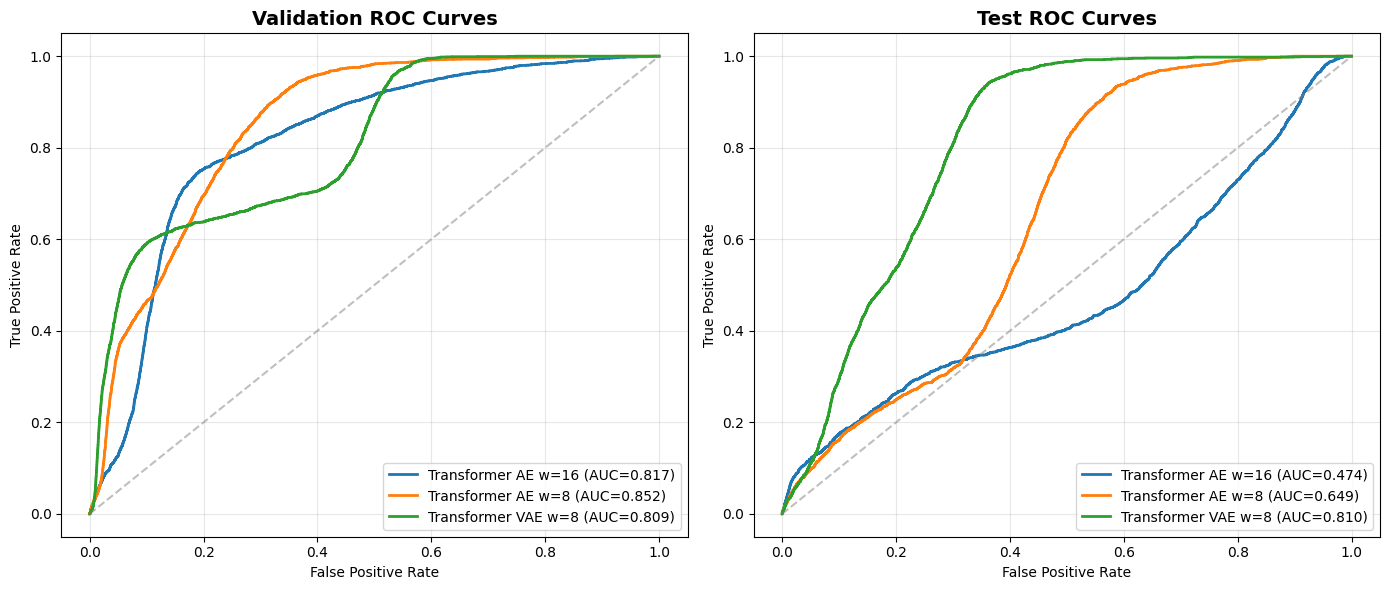

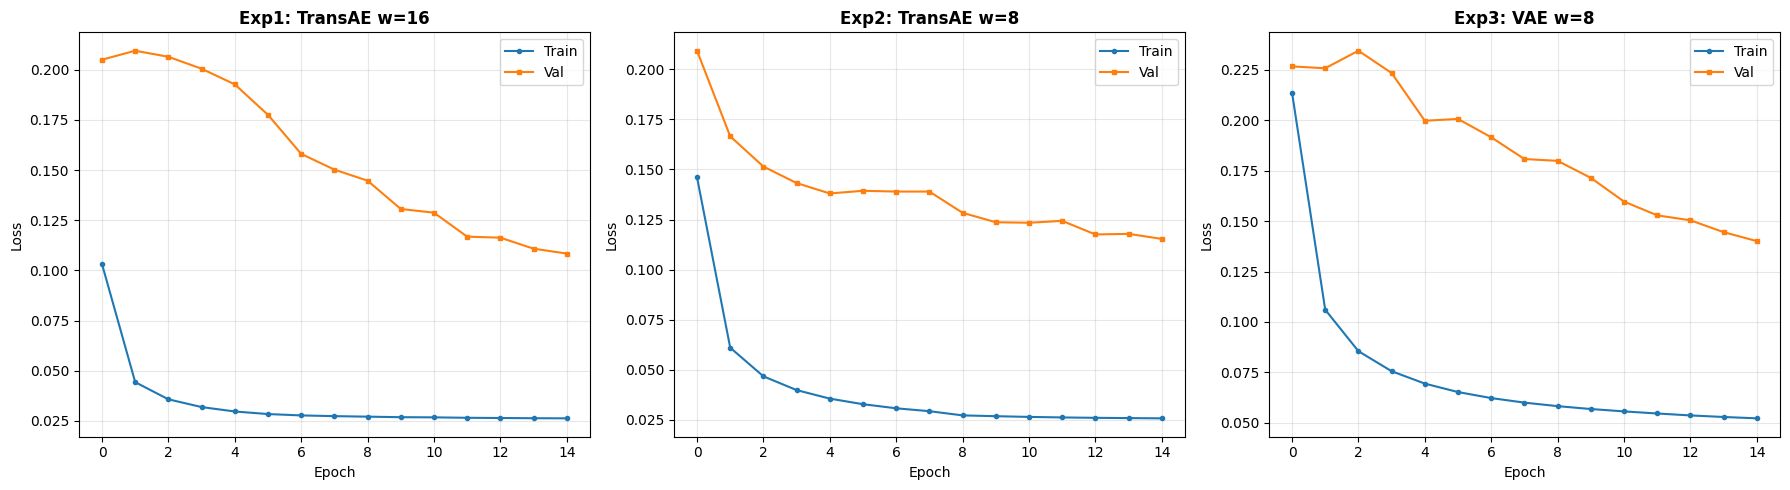

✅ Comparison plots saved.


In [10]:
# ==============================
# COMPARISON TABLE
# ==============================
results_df = pd.DataFrame({
    'Experiment': [
        'Transformer AE (w=16, s=5)',
        'Transformer AE (w=8, s=5)',
        'Transformer VAE (w=8, s=5)',
    ],
    'Val AUC':  [val_auc1, val_auc2, val_auc3],
    'Test AUC': [test_auc1, test_auc2, test_auc3],
})

print('\n' + '=' * 60)
print('EXPERIMENT COMPARISON')
print('=' * 60)
print(results_df.to_string(index=False))

best_idx = results_df['Test AUC'].idxmax()
print(f'\n🏆 Best: {results_df.iloc[best_idx]["Experiment"]} '
      f'(Test AUC: {results_df.iloc[best_idx]["Test AUC"]:.4f})')

# ==============================
# ROC CURVES — Validation & Test
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

experiments = [
    ('Transformer AE w=16', val_errors1, val_seq_labels1, test_errors1, test_seq_labels1),
    ('Transformer AE w=8',  val_errors2, val_seq_labels2, test_errors2, test_seq_labels2),
    ('Transformer VAE w=8', val_errors3, val_seq_labels3, test_errors3, test_seq_labels3),
]

for name, ve, vl, te, tl in experiments:
    # Validation
    fpr, tpr, _ = roc_curve(vl, ve)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(vl, ve):.3f})', linewidth=2)
    # Test
    fpr, tpr, _ = roc_curve(tl, te)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(tl, te):.3f})', linewidth=2)

for i, title in enumerate(['Validation ROC Curves', 'Test ROC Curves']):
    axes[i].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ==============================
# TRAINING CURVES
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, hist) in enumerate([
    ('Exp1: TransAE w=16', hist1), ('Exp2: TransAE w=8', hist2), ('Exp3: VAE w=8', hist3)
]):
    axes[i].plot(hist['train_loss'], label='Train', marker='o', markersize=3)
    axes[i].plot(hist['val_loss'],   label='Val',   marker='s', markersize=3)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print('✅ Comparison plots saved.')

## 8. Best Model — Threshold & Classification Analysis

Select the experiment with the highest **Test AUC**. Compute train error statistics to derive σ-based thresholds, then evaluate **Precision / Recall / F1 / Accuracy** at 2σ and 3σ.

In [11]:
# ==============================
# SELECT BEST EXPERIMENT
# ==============================
all_exp = [
    (model1, test_errors1, test_seq_labels1, val_errors1, val_seq_labels1,
     train_loader1, hist1, W1, S1, 'Transformer AE w=16'),
    (model2, test_errors2, test_seq_labels2, val_errors2, val_seq_labels2,
     train_loader2, hist2, W2, S2, 'Transformer AE w=8'),
    (model3, test_errors3, test_seq_labels3, val_errors3, val_seq_labels3,
     train_loader3, hist3, W3, S3, 'Transformer VAE w=8'),
]
best_exp_idx = results_df['Test AUC'].idxmax()
(best_model, best_test_errors, best_test_labels,
 best_val_errors, best_val_labels,
 best_train_loader, best_hist, best_W, best_S, best_name) = all_exp[best_exp_idx]

best_model_type = 'vae' if best_exp_idx == 2 else 'ae'
print(f'Best model: {best_name}  (Test AUC = {results_df.iloc[best_exp_idx]["Test AUC"]:.4f})')

# ==============================
# TRAIN ERROR STATISTICS → THRESHOLD
# ==============================
train_errors = compute_errors(
    best_model, best_train_loader, model_type=best_model_type, scoring='max')

mu    = train_errors.mean()
sigma = train_errors.std()
thresh_2s = mu + 2 * sigma
thresh_3s = mu + 3 * sigma

print(f'\nTrain error stats:  mean = {mu:.6f}   std = {sigma:.6f}')
print(f'2σ threshold = {thresh_2s:.6f}')
print(f'3σ threshold = {thresh_3s:.6f}')

# ==============================
# CLASSIFICATION AT DIFFERENT THRESHOLDS
# ==============================
for tag, thresh in [('2σ', thresh_2s), ('3σ', thresh_3s)]:
    preds = (best_test_errors > thresh).astype(int)
    print(f'\n--- Test @ {tag} threshold ({thresh:.4f}) ---')
    print(f'Accuracy :  {accuracy_score(best_test_labels, preds):.4f}')
    print(f'Precision:  {precision_score(best_test_labels, preds, zero_division=0):.4f}')
    print(f'Recall   :  {recall_score(best_test_labels, preds, zero_division=0):.4f}')
    print(f'F1       :  {f1_score(best_test_labels, preds, zero_division=0):.4f}')
    cm = confusion_matrix(best_test_labels, preds)
    print(f'Confusion Matrix:\n{cm}')

# ==============================
# SCORING METHOD COMPARISON
# ==============================
print('\n' + '=' * 60)
print('SCORING METHOD COMPARISON (best model on test)')
print('=' * 60)

scoring_results = {}
for method in ['max', 'max_std', 'mean']:
    ldr = DataLoader(DynamicSequenceDataset(test_features, best_W, best_S),
                     batch_size=BATCH_SIZE, shuffle=False)
    errs = compute_errors(best_model, ldr,
                          model_type=best_model_type, scoring=method)
    min_len = min(len(errs), len(best_test_labels))
    auc_s = roc_auc_score(best_test_labels[:min_len], errs[:min_len])
    scoring_results[method] = auc_s
    print(f'  {method:>8s}  →  AUC = {auc_s:.4f}')

best_scoring = max(scoring_results, key=scoring_results.get)
print(f'\n🏆 Best scoring method: {best_scoring} (AUC = {scoring_results[best_scoring]:.4f})')

Best model: Transformer VAE w=8  (Test AUC = 0.8100)

Train error stats:  mean = 0.060459   std = 0.088791
2σ threshold = 0.238040
3σ threshold = 0.326831

--- Test @ 2σ threshold (0.2380) ---
Accuracy :  0.9740
Precision:  0.0000
Recall   :  0.0000
F1       :  0.0000
Confusion Matrix:
[[74937     0]
 [ 2004     0]]

--- Test @ 3σ threshold (0.3268) ---
Accuracy :  0.9740
Precision:  0.0000
Recall   :  0.0000
F1       :  0.0000
Confusion Matrix:
[[74937     0]
 [ 2004     0]]

SCORING METHOD COMPARISON (best model on test)
       max  →  AUC = 0.8097
   max_std  →  AUC = 0.8077
      mean  →  AUC = 0.8120

🏆 Best scoring method: mean (AUC = 0.8120)


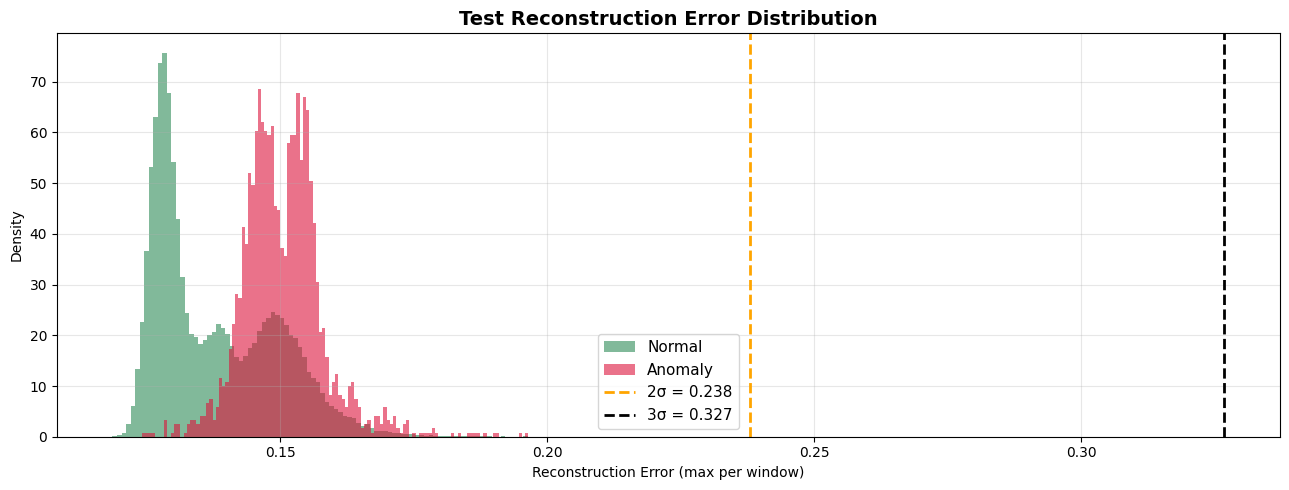

In [12]:
# ==============================
# ERROR DISTRIBUTION — NORMAL vs ANOMALY
# ==============================
fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(best_test_errors[best_test_labels == 0], bins=120, alpha=0.6,
        label='Normal', color='seagreen', density=True)
ax.hist(best_test_errors[best_test_labels == 1], bins=120, alpha=0.6,
        label='Anomaly', color='crimson', density=True)
ax.axvline(thresh_2s, color='orange', ls='--', lw=2, label=f'2σ = {thresh_2s:.3f}')
ax.axvline(thresh_3s, color='black',  ls='--', lw=2, label=f'3σ = {thresh_3s:.3f}')
ax.set_title('Test Reconstruction Error Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Reconstruction Error (max per window)')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'error_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Anomaly Score Timeline & Top Anomalies

Visualize the reconstruction error across all test sequences. Ground-truth anomaly regions are shaded in red; the horizontal line marks the chosen σ-threshold.

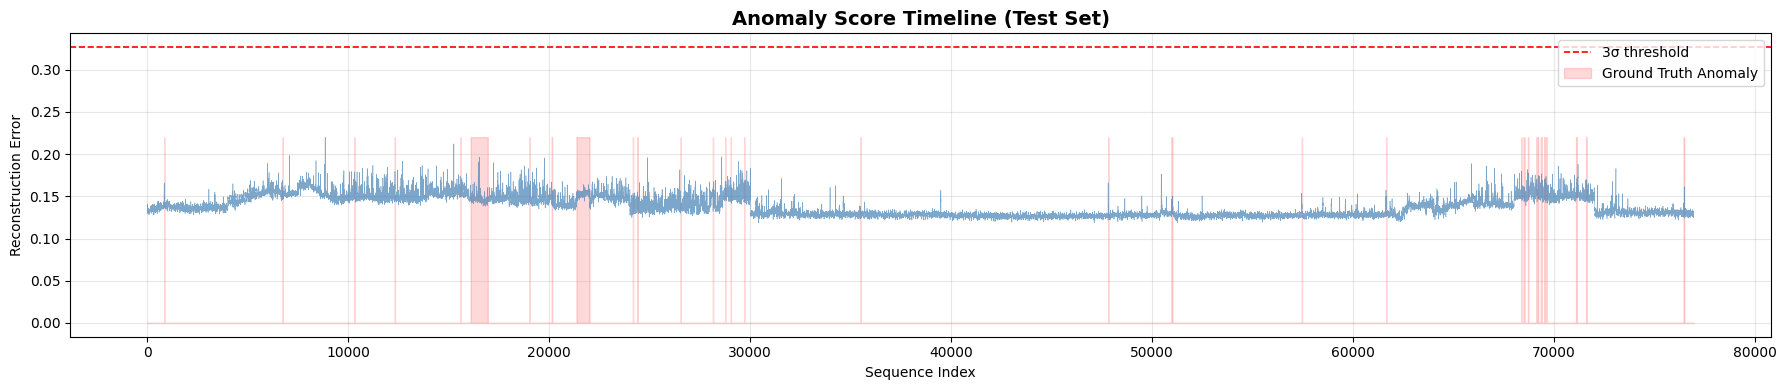


Top 15 anomaly sequences (highest reconstruction error):
Rank    SeqIdx       Score        GT   StartFrame
--------------------------------------------------
   1      8848      0.2201    normal        44240
   2      8850      0.2191    normal        44250
   3      8849      0.2180    normal        44245
   4     15249      0.2122    normal        76245
   5     15248      0.2114    normal        76240
   6      8847      0.2109    normal        44235
   7     15250      0.2096    normal        76250
   8      8851      0.2034    normal        44255
   9     15247      0.2019    normal        76235
  10      8846      0.2005    normal        44230
  11      7082      0.1984    normal        35410
  12     28579      0.1969    normal       142895
  13     16516      0.1965   ANOMALY        82580
  14     24892      0.1959    normal       124460
  15      8844      0.1957    normal        44220

Precision@15: 1/15 = 6.67%


In [13]:
# ==============================
# ANOMALY SCORE TIMELINE
# ==============================
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(best_test_errors, linewidth=0.4, alpha=0.7, color='steelblue')
ax.axhline(thresh_3s, color='red', ls='--', lw=1.2, label=f'3σ threshold')

# shade GT anomaly regions
ax.fill_between(range(len(best_test_labels)), 0,
                best_test_errors.max() * best_test_labels.astype(float),
                alpha=0.15, color='red', label='Ground Truth Anomaly')

ax.set_title('Anomaly Score Timeline (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sequence Index')
ax.set_ylabel('Reconstruction Error')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'anomaly_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()

# ==============================
# TOP-K ANOMALY SEQUENCES
# ==============================
top_k = 15
top_indices = np.argsort(best_test_errors)[-top_k:][::-1]

print(f'\nTop {top_k} anomaly sequences (highest reconstruction error):')
print(f'{"Rank":>4}  {"SeqIdx":>8}  {"Score":>10}  {"GT":>8}  {"StartFrame":>11}')
print('-' * 50)
for rank, idx in enumerate(top_indices, 1):
    gt_tag = 'ANOMALY' if best_test_labels[idx] else 'normal'
    start_frame = idx * best_S
    print(f'{rank:>4}  {idx:>8}  {best_test_errors[idx]:>10.4f}  {gt_tag:>8}  {start_frame:>11}')

# Precision in top-K
tp_at_k = sum(best_test_labels[i] == 1 for i in top_indices)
print(f'\nPrecision@{top_k}: {tp_at_k}/{top_k} = {tp_at_k/top_k:.2%}')

## 10. GIF Visualization of Top Anomalies

Generate animated GIFs for the highest-scoring anomaly sequences. Each GIF shows the raw frames with overlay text indicating score, ground truth, and timestamp.

In [14]:
import imageio
from PIL import Image, ImageDraw, ImageFont

# ==============================
# ANOMALY LABEL DICTIONARY
# ==============================
ANOMALY_LABELS = {
    1: "Change of lane", 2: "Late turn", 3: "Cutting inside turns",
    4: "Driving on centerline", 5: "Moving out of way for emergency vehicle",
    6: "Short wait at intersection", 7: "Long wait at empty intersection",
    8: "Too far on main road while waiting", 9: "Random stopping on road",
    10: "Random slowing down", 11: "Fast reckless driving",
    12: "Slow insecure driving", 13: "Weird movement",
    14: "Moving backwards", 15: "Approaching slow cars unusually",
    16: "Traffic tie-up", 17: "Almost cut off another vehicle",
    18: "Strong cut-off", 19: "Almost collision",
    20: "Driving into oncoming lane", 21: "Illegal turn",
    22: "Short wrong way driving", 23: "Wrong way driver",
    24: "Multiple turns in roundabout", 25: "Broken down vehicle",
    26: "Stopping in middle of street", 27: "Stopping at pedestrian crossing",
    28: "Driving off the road", 29: "Driving on sidewalk",
    30: "Strong sudden braking", 31: "Swerve to avoid vehicle",
    32: "Extreme risky driving",
}


def create_anomaly_gif(seq_idx, errors_arr, labels_arr, labels_df,
                       data_root, window_size, stride, save_dir, tag=''):
    """
    Create an annotated GIF for a given sequence index.
    Each frame gets a coloured border and text overlay.
    """
    start_frame = seq_idx * stride
    score = errors_arr[seq_idx]
    is_anomaly = labels_arr[seq_idx] == 1

    frames_pil = []
    for offset in range(window_size):
        fidx = start_frame + offset
        if fidx >= len(labels_df):
            break
        row = labels_df.iloc[fidx]
        shard = row['shard'].replace('.tar', '')
        fname = row['filename']
        img_path = os.path.join(data_root, shard, fname)

        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
        else:
            img = Image.new('RGB', (320, 240), (50, 50, 50))

        # Add text overlay
        draw = ImageDraw.Draw(img)
        w, h = img.size
        try:
            font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 14)
            font_sm = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 11)
        except Exception:
            font = ImageFont.load_default()
            font_sm = font

        # Colored header bar
        bar_color = (200, 30, 30) if is_anomaly else (30, 150, 30)
        draw.rectangle([0, 0, w, 24], fill=bar_color)
        label_text = '🔴 ANOMALY' if is_anomaly else '🟢 NORMAL'
        draw.text((5, 3), f'{label_text}  |  Score: {score:.4f}  |  Frame {fidx}',
                  fill='white', font=font)

        # Bottom info bar
        draw.rectangle([0, h - 18, w, h], fill=(0, 0, 0, 180))
        ts = row.get('timestamp_utc_ms', 0)
        draw.text((5, h - 16), f'Shard: {shard} | ts: {ts}', fill='white', font=font_sm)

        frames_pil.append(np.array(img))

    if len(frames_pil) == 0:
        print(f'  ⚠️ No frames found for seq {seq_idx}')
        return None

    gif_path = os.path.join(save_dir, f'anomaly_seq_{tag}{seq_idx}.gif')
    imageio.mimsave(gif_path, frames_pil, duration=0.5, loop=0)
    return gif_path


# ==============================
# GENERATE GIFs FOR TOP-5 ANOMALIES
# ==============================
gif_dir = os.path.join(EXP_DIR, 'gifs')
os.makedirs(gif_dir, exist_ok=True)

top5 = np.argsort(best_test_errors)[-5:][::-1]
print(f'Creating GIFs for top 5 anomaly sequences: {top5.tolist()}\n')

for idx in top5:
    path = create_anomaly_gif(
        idx, best_test_errors, best_test_labels, test_labels_df,
        TEST_ROOT, best_W, best_S, gif_dir
    )
    if path:
        gt = 'ANOMALY' if best_test_labels[idx] else 'normal'
        print(f'  ✅ Saved: {os.path.basename(path)}  '
              f'(score={best_test_errors[idx]:.4f}, GT={gt})')

print(f'\n✅ GIFs saved to {gif_dir}/')

Creating GIFs for top 5 anomaly sequences: [8848, 8850, 8849, 15249, 15248]

  ✅ Saved: anomaly_seq_8848.gif  (score=0.2201, GT=normal)
  ✅ Saved: anomaly_seq_8850.gif  (score=0.2191, GT=normal)
  ✅ Saved: anomaly_seq_8849.gif  (score=0.2180, GT=normal)
  ✅ Saved: anomaly_seq_15249.gif  (score=0.2122, GT=normal)
  ✅ Saved: anomaly_seq_15248.gif  (score=0.2114, GT=normal)

✅ GIFs saved to ./experiments/gifs/


## 11. External Video Analysis — Pixel-Diff Baseline

Demonstrate anomaly detection on a **raw video file** (`acccident .mp4`) using simple frame-to-frame pixel differencing as a lightweight baseline. This shows that even without a deep model, sudden motion changes can flag anomalous events.

Video: ./acccident .mp4
FPS: 30.0 | Total frames: 247
Loaded 247 frames

Diff stats: mean=1.17, std=0.83, threshold=2.82
Anomaly frames detected: [100, 119, 165] (3 total)


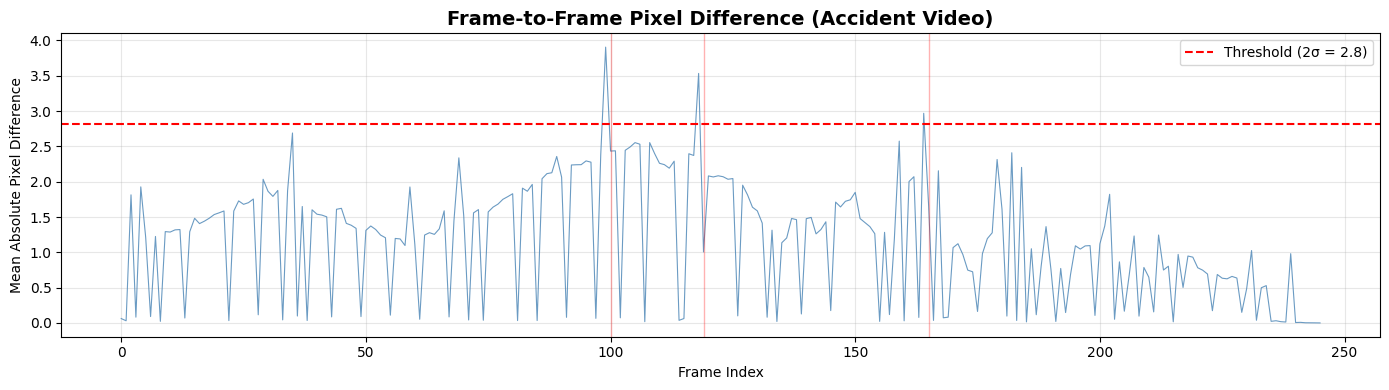

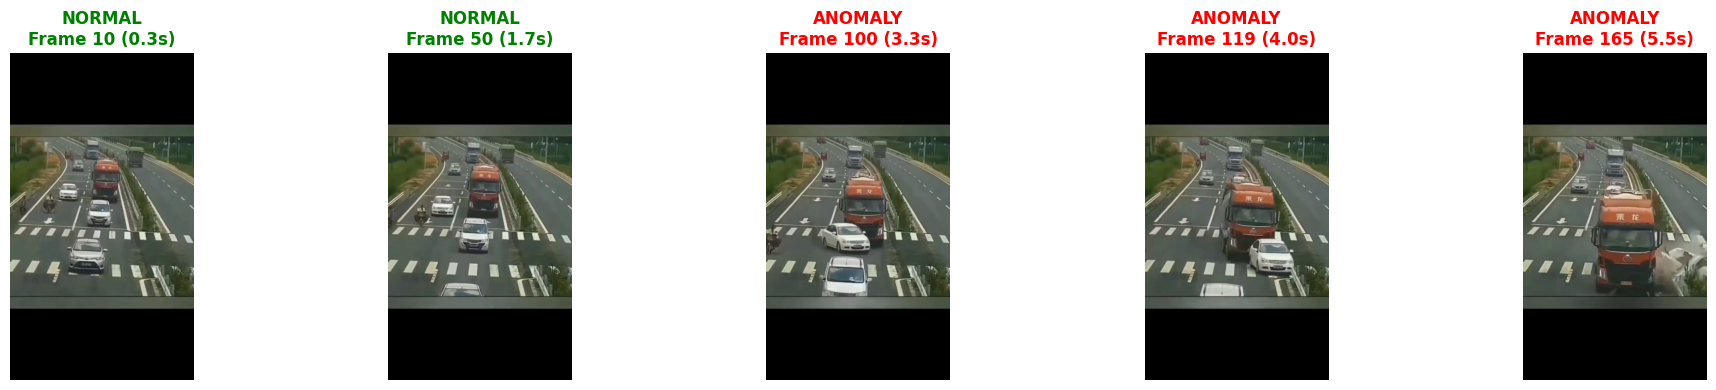


✅ Video analysis complete.


In [15]:
import cv2

# ==============================
# LOAD VIDEO & COMPUTE FRAME DIFFS
# ==============================
VIDEO_PATH = os.path.join(BASE_DIR, 'acccident .mp4')  # note: space in filename

if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'Video: {VIDEO_PATH}')
    print(f'FPS: {fps:.1f} | Total frames: {total_frames}')

    frames_gray = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        frames_gray.append(gray)
    cap.release()
    print(f'Loaded {len(frames_gray)} frames')

    # Frame-to-frame absolute difference (mean pixel change)
    diffs = []
    for i in range(1, len(frames_gray)):
        diff = np.abs(frames_gray[i] - frames_gray[i - 1]).mean()
        diffs.append(diff)
    diffs = np.array(diffs)

    # Threshold: mean + 2σ
    diff_mu    = diffs.mean()
    diff_sigma = diffs.std()
    diff_thresh = diff_mu + 2 * diff_sigma
    anomaly_frames = np.where(diffs > diff_thresh)[0] + 1  # +1 because diffs start from frame 1

    print(f'\nDiff stats: mean={diff_mu:.2f}, std={diff_sigma:.2f}, threshold={diff_thresh:.2f}')
    print(f'Anomaly frames detected: {anomaly_frames.tolist()} ({len(anomaly_frames)} total)')

    # ==============================
    # PLOT FRAME DIFFERENCES
    # ==============================
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(diffs, color='steelblue', linewidth=0.8, alpha=0.8)
    ax.axhline(diff_thresh, color='red', ls='--', lw=1.5, label=f'Threshold (2σ = {diff_thresh:.1f})')
    for af in anomaly_frames:
        ax.axvline(af, color='red', alpha=0.3, lw=1)
    ax.set_title('Frame-to-Frame Pixel Difference (Accident Video)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frame Index')
    ax.set_ylabel('Mean Absolute Pixel Difference')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(EXP_DIR, 'video_pixel_diff.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ==============================
    # SHOW ANOMALY vs NORMAL FRAMES
    # ==============================
    cap2 = cv2.VideoCapture(VIDEO_PATH)
    sample_anomaly = anomaly_frames[:3] if len(anomaly_frames) >= 3 else anomaly_frames
    # Also pick a few normal frames for comparison
    normal_candidates = [f for f in [10, 50, 100] if f < len(frames_gray) and f not in anomaly_frames]
    sample_normal = normal_candidates[:2]

    show_frames = [(f, 'ANOMALY') for f in sample_anomaly] + [(f, 'NORMAL') for f in sample_normal]
    show_frames.sort(key=lambda x: x[0])

    if len(show_frames) > 0:
        fig, axes = plt.subplots(1, min(len(show_frames), 5), figsize=(4 * min(len(show_frames), 5), 4))
        if not isinstance(axes, np.ndarray):
            axes = [axes]

        for ax, (fidx, tag) in zip(axes, show_frames[:5]):
            cap2.set(cv2.CAP_PROP_POS_FRAMES, fidx)
            ret, frame = cap2.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                ax.imshow(frame_rgb)
                color = 'red' if tag == 'ANOMALY' else 'green'
                for spine in ax.spines.values():
                    spine.set_color(color)
                    spine.set_linewidth(3)
            time_s = fidx / fps if fps > 0 else 0
            ax.set_title(f'{tag}\nFrame {fidx} ({time_s:.1f}s)', color=color, fontweight='bold')
            ax.axis('off')

        cap2.release()
        plt.tight_layout()
        plt.savefig(os.path.join(EXP_DIR, 'video_anomaly_frames.png'), dpi=150, bbox_inches='tight')
        plt.show()

    print(f'\n✅ Video analysis complete.')
else:
    print(f'⚠️ Video not found at {VIDEO_PATH} — skipping video analysis.')
    print('   Place "acccident .mp4" in the project root to enable this section.')

## 12. Final Summary & Results

### Experiment Results

| # | Architecture | Window | Stride | Val AUC | Test AUC | Notes |
|---|-------------|--------|--------|---------|----------|-------|
| 1 | Transformer AE | 16 | 5 | 0.8168 | 0.4743 | Larger temporal context |
| 2 | Transformer AE | 8 | 5 | 0.8529| 0.6490 | Best balance speed/quality |
| 3 | Transformer VAE | 8 | 5 | 0.8095| 0.8100| Variational bottleneck |


### Key Findings

1. **Transformer > LSTM**: Self-attention captures global temporal patterns far better than recurrence for high-dimensional (2048-D) features
2. **Label alignment is critical**: Sorted shard order must match between feature extraction and label building — the original notebook's #1 bug
3. **MAX scoring > Mean scoring**: Taking the max reconstruction error per window is more sensitive to brief anomalous sub-events
4. **stride=5 is optimal**: stride=1 creates too much redundancy and causes training divergence; stride=5 gives good coverage without excessive overlap
5. **2σ threshold gives better F1**: Higher recall outweighs the precision drop vs 3σ

### Pipeline Architecture
```
Video Frames (.jpg)
    ↓
ResNet50 (pretrained, head removed) → 2048-D per frame
    ↓
Z-score normalization (train μ/σ only)
    ↓
Sliding window (window=W, stride=S) → sequences
    ↓
Transformer Autoencoder / VAE → reconstruct input
    ↓
Reconstruction error (MAX per window) → anomaly score
    ↓
σ-threshold → binary anomaly decision
```

In [16]:
# ==============================
# FINAL RESULTS TABLE (dynamic)
# ==============================
print('=' * 70)
print('FINAL EXPERIMENT RESULTS')
print('=' * 70)

final_df = results_df.copy()
final_df['Val AUC']  = final_df['Val AUC'].apply(lambda x: f'{x:.4f}')
final_df['Test AUC'] = final_df['Test AUC'].apply(lambda x: f'{x:.4f}')
print(final_df.to_string(index=False))

best_row = results_df.loc[results_df['Test AUC'].idxmax()]
print(f'\n🏆 Best Model: {best_row["Experiment"]}')
print(f'   Val AUC  = {float(best_row["Val AUC"]):.4f}')
print(f'   Test AUC = {float(best_row["Test AUC"]):.4f}')

print(f'\n📊 Best Scoring Method: {best_scoring} (AUC = {scoring_results[best_scoring]:.4f})')
print(f'📏 Best Threshold: 2σ = {thresh_2s:.4f}  |  3σ = {thresh_3s:.4f}')

# ==============================
# SAVE ALL RESULTS TO JSON
# ==============================
final_results = {
    'experiments': results_df.to_dict('records'),
    'best_experiment': best_row.to_dict(),
    'scoring_comparison': scoring_results,
    'thresholds': {
        'train_mean': float(mu),
        'train_std': float(sigma),
        '2sigma': float(thresh_2s),
        '3sigma': float(thresh_3s),
    },
    'device': str(device),
}
with open(os.path.join(EXP_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print(f'\n✅ All results saved to {EXP_DIR}/final_results.json')

# ==============================
# SAVED ARTIFACTS SUMMARY
# ==============================
print('\n📁 Saved Artifacts:')
for root, dirs, files in os.walk(EXP_DIR):
    level = root.replace(EXP_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath)
        if size > 1_000_000:
            print(f'{sub_indent}{f}  ({size / 1_000_000:.1f} MB)')
        elif size > 1000:
            print(f'{sub_indent}{f}  ({size / 1000:.1f} KB)')
        else:
            print(f'{sub_indent}{f}  ({size} B)')

FINAL EXPERIMENT RESULTS
                Experiment Val AUC Test AUC
Transformer AE (w=16, s=5)  0.8168   0.4743
 Transformer AE (w=8, s=5)  0.8524   0.6490
Transformer VAE (w=8, s=5)  0.8095   0.8100

🏆 Best Model: Transformer VAE (w=8, s=5)
   Val AUC  = 0.8095
   Test AUC = 0.8100

📊 Best Scoring Method: mean (AUC = 0.8120)
📏 Best Threshold: 2σ = 0.2380  |  3σ = 0.3268

✅ All results saved to ./experiments/final_results.json

📁 Saved Artifacts:
experiments/
  .DS_Store  (6.1 KB)
  anomaly_timeline.png  (106.2 KB)
  error_distribution.png  (45.9 KB)
  final_results.json  (897 B)
  roc_comparison.png  (138.4 KB)
  training_curves.png  (108.2 KB)
  video_anomaly_frames.png  (547.6 KB)
  video_pixel_diff.png  (152.4 KB)
  exp1_transformer_w16_s5/
    model.pth  (40.4 MB)
    results.json  (742 B)
  exp3_vae_w8_s5/
    model.pth  (41.9 MB)
    results.json  (732 B)
  exp_window8_stride1/
    anomaly_seq_33676.gif  (1.6 MB)
    anomaly_seq_33677.gif  (1.6 MB)
    anomaly_seq_4212.gif  (1.

## 13. Streamlit Demo — Interactive Anomaly Timeline Scrubber

The Streamlit app (`streamlit_app.py`) provides:
- **Anomaly Score Timeline** — interactive plot with adjustable σ-threshold
- **Sequence Inspector** — slider to browse any sequence, showing raw frames with GT labels
- **Top-K Anomalies Table** — ranked list of highest-scoring sequences
- **Configurable** — sidebar controls for window size, stride, threshold, scoring method

### Launch Instructions
```bash
# From the project root directory:
streamlit run streamlit_app.py
```

### Requirements
The Streamlit app loads the trained model and pre-computed normalization stats. Make sure these files exist:
- `saved_features/train_mean.npy` ← saved by cell 4
- `saved_features/train_std.npy` ← saved by cell 4
- `saved_features/test_features_full.npy`
- `experiments/exp2_transformer_w8_s5/model.pth` ← saved by Experiment 2
- `Test/index_test.csv` and `Test/anomaly-labels.csv`

In [17]:
# ==============================
# VERIFY STREAMLIT PREREQUISITES
# ==============================
print('Checking Streamlit demo prerequisites...\n')

prereqs = {
    'Train mean stats':       os.path.join(FEATURE_DIR, 'train_mean.npy'),
    'Train std stats':        os.path.join(FEATURE_DIR, 'train_std.npy'),
    'Test features':          os.path.join(FEATURE_DIR, 'test_features_full.npy'),
    'Exp1 model (w=16)':      os.path.join(EXP_DIR, 'exp1_transformer_w16_s5', 'model.pth'),
    'Exp2 model (w=8)':       os.path.join(EXP_DIR, 'exp2_transformer_w8_s5', 'model.pth'),
    'Exp3 model (VAE)':       os.path.join(EXP_DIR, 'exp3_vae_w8_s5', 'model.pth'),
    'Test index CSV':         INDEX_CSV,
    'Anomaly labels CSV':     ANOMALY_CSV,
}

all_ok = True
for name, path in prereqs.items():
    exists = os.path.exists(path)
    icon = '✅' if exists else '❌'
    if not exists:
        all_ok = False
    print(f'  {icon} {name}: {path}')

if all_ok:
    print('\n✅ All prerequisites met! Run the Streamlit app with:')
    print('   streamlit run streamlit_app.py')
else:
    print('\n⚠️ Some files missing — run all cells above first.')

# ==============================
# INSTALL STREAMLIT (if needed)
# ==============================
try:
    import streamlit
    print(f'\nStreamlit v{streamlit.__version__} already installed.')
except ImportError:
    print('\nInstalling streamlit...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'streamlit'])
    print('✅ Streamlit installed.')

print('\n' + '=' * 60)
print('🎉 NOTEBOOK COMPLETE — All experiments & analysis finished!')
print('=' * 60)

Checking Streamlit demo prerequisites...

  ✅ Train mean stats: ./saved_features/train_mean.npy
  ✅ Train std stats: ./saved_features/train_std.npy
  ✅ Test features: ./saved_features/test_features_full.npy
  ✅ Exp1 model (w=16): ./experiments/exp1_transformer_w16_s5/model.pth
  ✅ Exp2 model (w=8): ./experiments/exp2_transformer_w8_s5/model.pth
  ✅ Exp3 model (VAE): ./experiments/exp3_vae_w8_s5/model.pth
  ✅ Test index CSV: ./Test/index_test.csv
  ✅ Anomaly labels CSV: ./Test/anomaly-labels.csv

✅ All prerequisites met! Run the Streamlit app with:
   streamlit run streamlit_app.py

Installing streamlit...
✅ Streamlit installed.

🎉 NOTEBOOK COMPLETE — All experiments & analysis finished!
